# Operaciones de Datos con Pandas

Este notebook cubre operaciones fundamentales de manipulación de datos con pandas:

1. **GroupBy y Agregaciones**: Cómo agrupar datos y calcular estadísticas resumidas
2. **Joins (Uniones)**: Los diferentes tipos de joins y cuándo usar cada uno
3. **Creación de Variables**: Cómo crear nuevas columnas derivadas

## Configuración Inicial

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configuración de visualización
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)

# Para reproducibilidad
np.random.seed(42)

## 1. Creación de Datasets de Ejemplo

Crearemos datasets de ejemplo que representan ventas de una tienda online.

In [2]:
# Dataset de ventas
ventas = pd.DataFrame({
    'id_venta': range(1, 21),
    'id_cliente': [101, 102, 103, 101, 104, 105, 102, 106, 103, 107,
                   101, 108, 104, 109, 105, 102, 110, 103, 106, 101],
    'id_producto': ['P1', 'P2', 'P1', 'P3', 'P2', 'P1', 'P3', 'P2', 'P1', 'P3',
                    'P2', 'P1', 'P3', 'P2', 'P3', 'P1', 'P2', 'P3', 'P1', 'P2'],
    'cantidad': np.random.randint(1, 10, 20),
    'precio_unitario': np.random.uniform(10, 100, 20).round(2),
    'fecha': pd.date_range('2024-01-01', periods=20, freq='D'),
    'region': np.random.choice(['Norte', 'Sur', 'Este', 'Oeste'], 20)
})

print("Dataset de Ventas:")
print(ventas.head(10))
print(f"\nDimensiones: {ventas.shape}")

Dataset de Ventas:
   id_venta  id_cliente id_producto  cantidad  precio_unitario      fecha  \
0         1         101          P1         7            65.57 2024-01-01   
1         2         102          P2         4            65.05 2024-01-02   
2         3         103          P1         8            10.64 2024-01-03   
3         4         101          P3         5            12.08 2024-01-04   
4         5         104          P2         7            57.23 2024-01-05   
5         6         105          P1         3            45.99 2024-01-06   
6         7         102          P3         7            14.20 2024-01-07   
7         8         106          P2         8            97.64 2024-01-08   
8         9         103          P1         5            30.95 2024-01-09   
9        10         107          P3         4            18.15 2024-01-10   

  region  
0    Sur  
1  Norte  
2    Sur  
3  Norte  
4    Sur  
5  Oeste  
6  Oeste  
7   Este  
8  Oeste  
9   Este  

Dimensiones

In [3]:
# Dataset de clientes
clientes = pd.DataFrame({
    'id_cliente': [101, 102, 103, 104, 105, 106, 107, 108, 109, 110],
    'nombre': ['Ana García', 'Carlos López', 'María Rodríguez', 'Juan Pérez', 
               'Laura Martínez', 'Pedro Sánchez', 'Isabel Torres', 'Miguel Ruiz',
               'Carmen Díaz', 'Francisco Moreno'],
    'edad': [28, 35, 42, 31, 26, 45, 38, 29, 33, 41],
    'ciudad': ['CDMX', 'Monterrey', 'Guadalajara', 'CDMX', 'Puebla',
               'CDMX', 'Monterrey', 'Guadalajara', 'CDMX', 'Puebla'],
    'tipo_cliente': ['Premium', 'Regular', 'Premium', 'Regular', 'Premium',
                     'Regular', 'Premium', 'Regular', 'Premium', 'Regular']
})

print("Dataset de Clientes:")
print(clientes)

Dataset de Clientes:
   id_cliente            nombre  edad       ciudad tipo_cliente
0         101        Ana García    28         CDMX      Premium
1         102      Carlos López    35    Monterrey      Regular
2         103   María Rodríguez    42  Guadalajara      Premium
3         104        Juan Pérez    31         CDMX      Regular
4         105    Laura Martínez    26       Puebla      Premium
5         106     Pedro Sánchez    45         CDMX      Regular
6         107     Isabel Torres    38    Monterrey      Premium
7         108       Miguel Ruiz    29  Guadalajara      Regular
8         109       Carmen Díaz    33         CDMX      Premium
9         110  Francisco Moreno    41       Puebla      Regular


In [4]:
# Dataset de productos
productos = pd.DataFrame({
    'id_producto': ['P1', 'P2', 'P3'],
    'nombre_producto': ['Laptop', 'Mouse', 'Teclado'],
    'categoria': ['Computadoras', 'Accesorios', 'Accesorios'],
    'costo_produccion': [400.0, 5.0, 15.0]
})

print("Dataset de Productos:")
print(productos)

Dataset de Productos:
  id_producto nombre_producto     categoria  costo_produccion
0          P1          Laptop  Computadoras             400.0
1          P2           Mouse    Accesorios               5.0
2          P3         Teclado    Accesorios              15.0


## 2. GroupBy y Agregaciones

El método `groupby()` es una de las operaciones más poderosas en pandas. Permite:
1. **Dividir** los datos en grupos basados en algún criterio
2. **Aplicar** una función a cada grupo
3. **Combinar** los resultados en una estructura de datos

Este patrón se conoce como **split-apply-combine**.

### 2.1 GroupBy Simple con Una Columna

In [5]:
# Agrupar por región y calcular el total de ventas
ventas['total'] = ventas['cantidad'] * ventas['precio_unitario']

ventas_por_region = ventas.groupby('region')['total'].sum()
print("Total de ventas por región:")
print(ventas_por_region)
print(f"\nTipo de objeto: {type(ventas_por_region)}")

Total de ventas por región:
region
Este     1602.73
Norte    1080.28
Oeste    1583.43
Sur      1276.78
Name: total, dtype: float64

Tipo de objeto: <class 'pandas.core.series.Series'>


### 2.2 Múltiples Agregaciones con agg()

In [6]:
# Aplicar múltiples funciones de agregación a una columna
estadisticas_region = ventas.groupby('region')['total'].agg([
    'sum',      # Suma total
    'mean',     # Promedio
    'count',    # Cantidad de ventas
    'min',      # Venta mínima
    'max',      # Venta máxima
    'std'       # Desviación estándar
])

print("Estadísticas de ventas por región:")
print(estadisticas_region.round(2))

Estadísticas de ventas por región:
            sum    mean  count    min     max     std
region                                               
Este    1602.73  400.68      4  72.60  781.12  295.26
Norte   1080.28  270.07      4  60.40  404.32  152.05
Oeste   1583.43  226.20      7  67.14  525.20  160.44
Sur     1276.78  255.36      5  85.12  458.99  164.78


### 2.3 Agregaciones en Múltiples Columnas

In [7]:
# Aplicar diferentes funciones a diferentes columnas
agregaciones = ventas.groupby('region').agg({
    'total': ['sum', 'mean'],
    'cantidad': ['sum', 'mean'],
    'id_venta': 'count'  # Contar número de transacciones
})

print("Agregaciones múltiples por región:")
print(agregaciones.round(2))

Agregaciones múltiples por región:
          total         cantidad       id_venta
            sum    mean      sum  mean    count
region                                         
Este    1602.73  400.68       23  5.75        4
Norte   1080.28  270.07       25  6.25        4
Oeste   1583.43  226.20       37  5.29        7
Sur     1276.78  255.36       26  5.20        5


### 2.4 GroupBy con Múltiples Columnas

In [8]:
# Agrupar por múltiples columnas
ventas_region_producto = ventas.groupby(['region', 'id_producto']).agg({
    'total': 'sum',
    'cantidad': 'sum',
    'id_venta': 'count'
}).rename(columns={'id_venta': 'num_transacciones'})

print("Ventas por región y producto:")
print(ventas_region_producto.round(2))

Ventas por región y producto:
                      total  cantidad  num_transacciones
region id_producto                                      
Este   P2           1093.18        14                  2
       P3            509.55         9                  2
Norte  P1            355.36         8                  1
       P2            664.52        12                  2
       P3             60.40         5                  1
Oeste  P1            292.72         8                  2
       P2            828.70        13                  2
       P3            462.01        16                  3
Sur    P1            876.17        19                  4
       P2            400.61         7                  1


In [9]:
# Resetear el índice para tener un DataFrame plano
ventas_region_producto_flat = ventas_region_producto.reset_index()
print("\nDataFrame con índice reseteado:")
print(ventas_region_producto_flat)


DataFrame con índice reseteado:
  region id_producto    total  cantidad  num_transacciones
0   Este          P2  1093.18        14                  2
1   Este          P3   509.55         9                  2
2  Norte          P1   355.36         8                  1
3  Norte          P2   664.52        12                  2
4  Norte          P3    60.40         5                  1
5  Oeste          P1   292.72         8                  2
6  Oeste          P2   828.70        13                  2
7  Oeste          P3   462.01        16                  3
8    Sur          P1   876.17        19                  4
9    Sur          P2   400.61         7                  1


### 2.5 Funciones Personalizadas con apply()

In [10]:
# Definir una función personalizada
def rango_precios(x):
    """Calcula el rango entre el precio máximo y mínimo"""
    return x.max() - x.min()

# Aplicar función personalizada
rangos = ventas.groupby('region')['precio_unitario'].apply(rango_precios)
print("Rango de precios por región:")
print(rangos.round(2))

Rango de precios por región:
region
Este     79.49
Norte    52.97
Oeste    87.30
Sur      84.16
Name: precio_unitario, dtype: float64


### 2.6 Transform: Mantener la Forma Original

In [11]:
# Transform devuelve un objeto del mismo tamaño que el input
# Útil para agregar columnas con estadísticas del grupo

ventas['promedio_region'] = ventas.groupby('region')['total'].transform('mean')
ventas['desviacion_promedio'] = ventas['total'] - ventas['promedio_region']

print("Ventas con promedio de región:")
print(ventas[['id_venta', 'region', 'total', 'promedio_region', 'desviacion_promedio']].head(10))

Ventas con promedio de región:
   id_venta region   total  promedio_region  desviacion_promedio
0         1    Sur  458.99       255.356000           203.634000
1         2  Norte  260.20       270.070000            -9.870000
2         3    Sur   85.12       255.356000          -170.236000
3         4  Norte   60.40       270.070000          -209.670000
4         5    Sur  400.61       255.356000           145.254000
5         6  Oeste  137.97       226.204286           -88.234286
6         7  Oeste   99.40       226.204286          -126.804286
7         8   Este  781.12       400.682500           380.437500
8         9  Oeste  154.75       226.204286           -71.454286
9        10   Este   72.60       400.682500          -328.082500


### 2.7 Visualización de Agregaciones

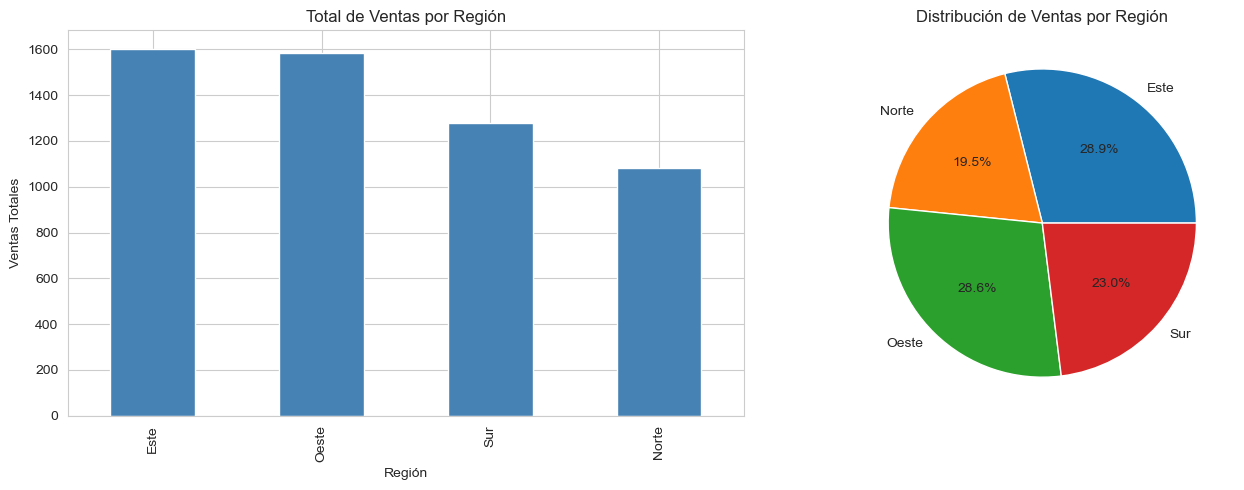

In [12]:
# Crear visualización de ventas por región
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfico de barras
ventas_por_region.sort_values(ascending=False).plot(
    kind='bar', 
    ax=axes[0],
    color='steelblue'
)
axes[0].set_title('Total de Ventas por Región')
axes[0].set_ylabel('Ventas Totales')
axes[0].set_xlabel('Región')

# Gráfico de pie
ventas_por_region.plot(
    kind='pie',
    ax=axes[1],
    autopct='%1.1f%%'
)
axes[1].set_title('Distribución de Ventas por Región')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## 3. Joins (Uniones de DataFrames)

Los joins permiten combinar dos DataFrames basándose en una o más columnas comunes (llaves). Pandas ofrece varios tipos de joins:

1. **Inner Join**: Solo mantiene las filas que tienen coincidencias en ambos DataFrames
2. **Left Join**: Mantiene todas las filas del DataFrame izquierdo
3. **Right Join**: Mantiene todas las filas del DataFrame derecho
4. **Outer Join**: Mantiene todas las filas de ambos DataFrames

### 3.1 Inner Join (Intersección)

In [13]:
# Inner join: Solo mantiene clientes que tienen ventas
ventas_con_clientes = pd.merge(
    ventas,
    clientes,
    on='id_cliente',
    how='inner'
)

print("Inner Join - Ventas con información de clientes:")
print(ventas_con_clientes[['id_venta', 'id_cliente', 'nombre', 'ciudad', 'total']].head(10))
print(f"\nNúmero de filas: {len(ventas_con_clientes)}")

Inner Join - Ventas con información de clientes:
   id_venta  id_cliente           nombre       ciudad   total
0         1         101       Ana García         CDMX  458.99
1         2         102     Carlos López    Monterrey  260.20
2         3         103  María Rodríguez  Guadalajara   85.12
3         4         101       Ana García         CDMX   60.40
4         5         104       Juan Pérez         CDMX  400.61
5         6         105   Laura Martínez       Puebla  137.97
6         7         102     Carlos López    Monterrey   99.40
7         8         106    Pedro Sánchez         CDMX  781.12
8         9         103  María Rodríguez  Guadalajara  154.75
9        10         107    Isabel Torres    Monterrey   72.60

Número de filas: 20


### 3.2 Left Join (Todas las filas del izquierdo)

In [14]:
# Crear un cliente adicional sin ventas para demostrar
clientes_extended = pd.concat([
    clientes,
    pd.DataFrame({
        'id_cliente': [111, 112],
        'nombre': ['Roberto Silva', 'Andrea Vargas'],
        'edad': [30, 27],
        'ciudad': ['CDMX', 'Monterrey'],
        'tipo_cliente': ['Regular', 'Premium']
    })
], ignore_index=True)

# Left join: Mantiene todos los clientes, incluso sin ventas
clientes_con_ventas = pd.merge(
    clientes_extended,
    ventas,
    on='id_cliente',
    how='left'
)

print("Left Join - Todos los clientes con sus ventas (si existen):")
print(clientes_con_ventas[['id_cliente', 'nombre', 'id_venta', 'total']].tail(15))
print(f"\nNúmero de filas: {len(clientes_con_ventas)}")

# Identificar clientes sin ventas
clientes_sin_ventas = clientes_con_ventas[clientes_con_ventas['id_venta'].isna()]['nombre'].unique()
print(f"\nClientes sin ventas: {list(clientes_sin_ventas)}")

Left Join - Todos los clientes con sus ventas (si existen):
    id_cliente            nombre  id_venta   total
7          103   María Rodríguez       3.0   85.12
8          103   María Rodríguez       9.0  154.75
9          103   María Rodríguez      18.0   67.14
10         104        Juan Pérez       5.0  400.61
11         104        Juan Pérez      13.0  295.47
12         105    Laura Martínez       6.0  137.97
13         105    Laura Martínez      15.0  436.95
14         106     Pedro Sánchez       8.0  781.12
15         106     Pedro Sánchez      19.0  189.60
16         107     Isabel Torres      10.0   72.60
17         108       Miguel Ruiz      12.0  355.36
18         109       Carmen Díaz      14.0  312.06
19         110  Francisco Moreno      17.0  404.32
20         111     Roberto Silva       NaN     NaN
21         112     Andrea Vargas       NaN     NaN

Número de filas: 22

Clientes sin ventas: ['Roberto Silva', 'Andrea Vargas']


### 3.3 Right Join (Todas las filas del derecho)

In [15]:
# Right join: Equivalente a left join con orden invertido
ventas_con_info = pd.merge(
    clientes_extended,
    ventas,
    on='id_cliente',
    how='right'  # Mantiene todas las ventas
)

print("Right Join - Todas las ventas con información de cliente:")
print(ventas_con_info[['id_venta', 'id_cliente', 'nombre', 'total']].head(10))
print(f"\nNúmero de filas: {len(ventas_con_info)}")

Right Join - Todas las ventas con información de cliente:
   id_venta  id_cliente           nombre   total
0         1         101       Ana García  458.99
1         2         102     Carlos López  260.20
2         3         103  María Rodríguez   85.12
3         4         101       Ana García   60.40
4         5         104       Juan Pérez  400.61
5         6         105   Laura Martínez  137.97
6         7         102     Carlos López   99.40
7         8         106    Pedro Sánchez  781.12
8         9         103  María Rodríguez  154.75
9        10         107    Isabel Torres   72.60

Número de filas: 20


### 3.4 Outer Join (Unión completa)

In [16]:
# Outer join: Mantiene todas las filas de ambos DataFrames
union_completa = pd.merge(
    clientes_extended,
    ventas,
    on='id_cliente',
    how='outer'
)

print("Outer Join - Todos los clientes y todas las ventas:")
print(union_completa[['id_cliente', 'nombre', 'id_venta', 'total']].tail(15))
print(f"\nNúmero de filas: {len(union_completa)}")

Outer Join - Todos los clientes y todas las ventas:
    id_cliente            nombre  id_venta   total
7          103   María Rodríguez       3.0   85.12
8          103   María Rodríguez       9.0  154.75
9          103   María Rodríguez      18.0   67.14
10         104        Juan Pérez       5.0  400.61
11         104        Juan Pérez      13.0  295.47
12         105    Laura Martínez       6.0  137.97
13         105    Laura Martínez      15.0  436.95
14         106     Pedro Sánchez       8.0  781.12
15         106     Pedro Sánchez      19.0  189.60
16         107     Isabel Torres      10.0   72.60
17         108       Miguel Ruiz      12.0  355.36
18         109       Carmen Díaz      14.0  312.06
19         110  Francisco Moreno      17.0  404.32
20         111     Roberto Silva       NaN     NaN
21         112     Andrea Vargas       NaN     NaN

Número de filas: 22


### 3.5 Join con Múltiples DataFrames

In [17]:
# Combinar ventas, clientes y productos
analisis_completo = pd.merge(
    ventas,
    clientes,
    on='id_cliente',
    how='inner'
)

analisis_completo = pd.merge(
    analisis_completo,
    productos,
    on='id_producto',
    how='inner'
)

print("Análisis completo con tres DataFrames:")
print(analisis_completo[[
    'id_venta', 'nombre', 'ciudad', 'tipo_cliente',
    'nombre_producto', 'categoria', 'cantidad', 'total'
]].head(10))

Análisis completo con tres DataFrames:
   id_venta           nombre       ciudad tipo_cliente nombre_producto  \
0         1       Ana García         CDMX      Premium          Laptop   
1         2     Carlos López    Monterrey      Regular           Mouse   
2         3  María Rodríguez  Guadalajara      Premium          Laptop   
3         4       Ana García         CDMX      Premium         Teclado   
4         5       Juan Pérez         CDMX      Regular           Mouse   
5         6   Laura Martínez       Puebla      Premium          Laptop   
6         7     Carlos López    Monterrey      Regular         Teclado   
7         8    Pedro Sánchez         CDMX      Regular           Mouse   
8         9  María Rodríguez  Guadalajara      Premium          Laptop   
9        10    Isabel Torres    Monterrey      Premium         Teclado   

      categoria  cantidad   total  
0  Computadoras         7  458.99  
1    Accesorios         4  260.20  
2  Computadoras         8   85.12  
3 

### 3.6 Join con Nombres de Columnas Diferentes

In [18]:
# Crear un DataFrame con nombres de columna diferentes
descuentos = pd.DataFrame({
    'cliente_id': [101, 102, 103, 104, 105],  # Nombre diferente
    'descuento': [0.1, 0.05, 0.15, 0.0, 0.2]
})

# Usar left_on y right_on para columnas con nombres diferentes
ventas_con_descuento = pd.merge(
    ventas,
    descuentos,
    left_on='id_cliente',
    right_on='cliente_id',
    how='left'
)

# Rellenar descuentos faltantes con 0
ventas_con_descuento['descuento'] = ventas_con_descuento['descuento'].fillna(0)

print("Ventas con descuentos aplicables:")
print(ventas_con_descuento[['id_venta', 'id_cliente', 'total', 'descuento']].head(10))

Ventas con descuentos aplicables:
   id_venta  id_cliente   total  descuento
0         1         101  458.99       0.10
1         2         102  260.20       0.05
2         3         103   85.12       0.15
3         4         101   60.40       0.10
4         5         104  400.61       0.00
5         6         105  137.97       0.20
6         7         102   99.40       0.05
7         8         106  781.12       0.00
8         9         103  154.75       0.15
9        10         107   72.60       0.00


### 3.7 Visualización de Tipos de Joins

Comparación de tipos de join:
  Tipo de Join  Número de Filas
0        inner               20
1         left               22
2        right               20
3        outer               22


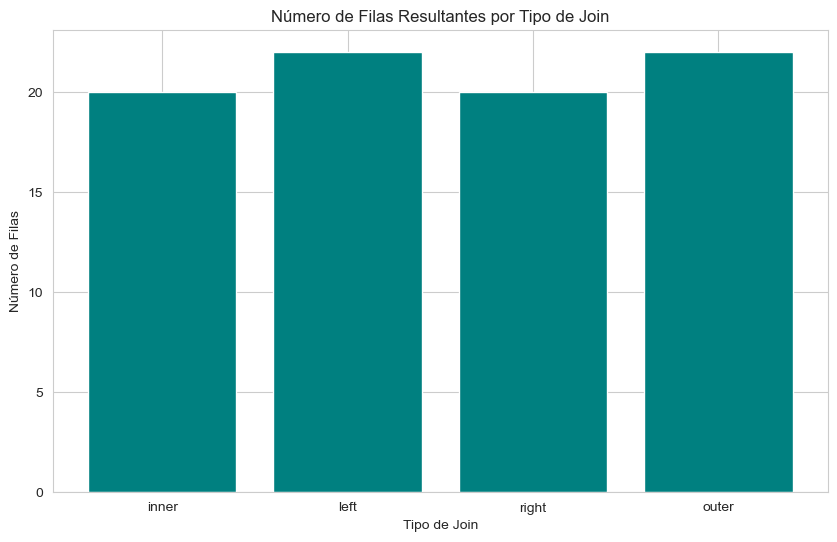

In [19]:
# Comparar el número de filas según tipo de join
join_types = ['inner', 'left', 'right', 'outer']
num_filas = []

for join_type in join_types:
    resultado = pd.merge(clientes_extended, ventas, on='id_cliente', how=join_type)
    num_filas.append(len(resultado))

comparacion_joins = pd.DataFrame({
    'Tipo de Join': join_types,
    'Número de Filas': num_filas
})

print("Comparación de tipos de join:")
print(comparacion_joins)

# Visualizar
plt.figure(figsize=(10, 6))
plt.bar(comparacion_joins['Tipo de Join'], comparacion_joins['Número de Filas'], color='teal')
plt.title('Número de Filas Resultantes por Tipo de Join')
plt.ylabel('Número de Filas')
plt.xlabel('Tipo de Join')
plt.show()

## 4. Creación de Nuevas Variables

Crear nuevas variables (columnas) es una parte fundamental del análisis de datos. Permite:
- Calcular métricas derivadas
- Transformar variables existentes
- Crear categorías o segmentos
- Generar features para modelos de machine learning

### 4.1 Variables Aritméticas Simples

In [20]:
# Calcular margen de ganancia
analisis_completo['margen'] = analisis_completo['precio_unitario'] - analisis_completo['costo_produccion']
analisis_completo['margen_porcentual'] = (
    analisis_completo['margen'] / analisis_completo['precio_unitario'] * 100
)

# Ganancia total por venta
analisis_completo['ganancia_total'] = analisis_completo['margen'] * analisis_completo['cantidad']

print("Variables de ganancia:")
print(analisis_completo[[
    'id_venta', 'nombre_producto', 'precio_unitario', 
    'costo_produccion', 'margen', 'margen_porcentual', 'ganancia_total'
]].head(10).round(2))

Variables de ganancia:
   id_venta nombre_producto  precio_unitario  costo_produccion  margen  \
0         1          Laptop            65.57             400.0 -334.43   
1         2           Mouse            65.05               5.0   60.05   
2         3          Laptop            10.64             400.0 -389.36   
3         4         Teclado            12.08              15.0   -2.92   
4         5           Mouse            57.23               5.0   52.23   
5         6          Laptop            45.99             400.0 -354.01   
6         7         Teclado            14.20              15.0   -0.80   
7         8           Mouse            97.64               5.0   92.64   
8         9          Laptop            30.95             400.0 -369.05   
9        10         Teclado            18.15              15.0    3.15   

   margen_porcentual  ganancia_total  
0            -510.04        -2341.01  
1              92.31          240.20  
2           -3659.40        -3114.88  
3     

### 4.2 Variables Categóricas con Condiciones

In [21]:
# Clasificar ventas por tamaño
def clasificar_venta(total):
    if total < 100:
        return 'Pequeña'
    elif total < 300:
        return 'Mediana'
    else:
        return 'Grande'

analisis_completo['tamaño_venta'] = analisis_completo['total'].apply(clasificar_venta)

# Alternativamente, usar pd.cut para binning
analisis_completo['categoria_total'] = pd.cut(
    analisis_completo['total'],
    bins=[0, 100, 300, float('inf')],
    labels=['Bajo', 'Medio', 'Alto']
)

print("Variables categóricas:")
print(analisis_completo[['id_venta', 'total', 'tamaño_venta', 'categoria_total']].head(10))

Variables categóricas:
   id_venta   total tamaño_venta categoria_total
0         1  458.99       Grande            Alto
1         2  260.20      Mediana           Medio
2         3   85.12      Pequeña            Bajo
3         4   60.40      Pequeña            Bajo
4         5  400.61       Grande            Alto
5         6  137.97      Mediana           Medio
6         7   99.40      Pequeña            Bajo
7         8  781.12       Grande            Alto
8         9  154.75      Mediana           Medio
9        10   72.60      Pequeña            Bajo


### 4.3 Variables con Condicionales (np.where)

In [22]:
# Identificar si el cliente es de CDMX
analisis_completo['es_cdmx'] = np.where(
    analisis_completo['ciudad'] == 'CDMX',
    'Sí',
    'No'
)

# Cliente joven (menor de 30 años)
analisis_completo['cliente_joven'] = np.where(
    analisis_completo['edad'] < 30,
    True,
    False
)

# Venta de alto valor con descuento
analisis_completo = pd.merge(
    analisis_completo,
    descuentos,
    left_on='id_cliente',
    right_on='cliente_id',
    how='left'
)
analisis_completo['descuento'] = analisis_completo['descuento'].fillna(0)

analisis_completo['venta_premium'] = np.where(
    (analisis_completo['total'] > 200) & (analisis_completo['descuento'] > 0),
    'Premium con descuento',
    'Estándar'
)

print("Variables condicionales:")
print(analisis_completo[[
    'id_venta', 'nombre', 'ciudad', 'es_cdmx', 
    'edad', 'cliente_joven', 'total', 'venta_premium'
]].head(10))

Variables condicionales:
   id_venta           nombre       ciudad es_cdmx  edad  cliente_joven  \
0         1       Ana García         CDMX      Sí    28           True   
1         2     Carlos López    Monterrey      No    35          False   
2         3  María Rodríguez  Guadalajara      No    42          False   
3         4       Ana García         CDMX      Sí    28           True   
4         5       Juan Pérez         CDMX      Sí    31          False   
5         6   Laura Martínez       Puebla      No    26           True   
6         7     Carlos López    Monterrey      No    35          False   
7         8    Pedro Sánchez         CDMX      Sí    45          False   
8         9  María Rodríguez  Guadalajara      No    42          False   
9        10    Isabel Torres    Monterrey      No    38          False   

    total          venta_premium  
0  458.99  Premium con descuento  
1  260.20  Premium con descuento  
2   85.12               Estándar  
3   60.40           

### 4.4 Variables Temporales (Date Features)

In [23]:
# Extraer componentes de fecha
analisis_completo['año'] = analisis_completo['fecha'].dt.year
analisis_completo['mes'] = analisis_completo['fecha'].dt.month
analisis_completo['dia'] = analisis_completo['fecha'].dt.day
analisis_completo['dia_semana'] = analisis_completo['fecha'].dt.day_name()
analisis_completo['trimestre'] = analisis_completo['fecha'].dt.quarter
analisis_completo['es_fin_semana'] = analisis_completo['fecha'].dt.dayofweek >= 5

print("Variables temporales:")
print(analisis_completo[[
    'id_venta', 'fecha', 'año', 'mes', 'dia', 
    'dia_semana', 'trimestre', 'es_fin_semana'
]].head(10))

Variables temporales:
   id_venta      fecha   año  mes  dia dia_semana  trimestre  es_fin_semana
0         1 2024-01-01  2024    1    1     Monday          1          False
1         2 2024-01-02  2024    1    2    Tuesday          1          False
2         3 2024-01-03  2024    1    3  Wednesday          1          False
3         4 2024-01-04  2024    1    4   Thursday          1          False
4         5 2024-01-05  2024    1    5     Friday          1          False
5         6 2024-01-06  2024    1    6   Saturday          1           True
6         7 2024-01-07  2024    1    7     Sunday          1           True
7         8 2024-01-08  2024    1    8     Monday          1          False
8         9 2024-01-09  2024    1    9    Tuesday          1          False
9        10 2024-01-10  2024    1   10  Wednesday          1          False


### 4.5 Variables de Texto (String Operations)

In [24]:
# Extraer primer nombre
analisis_completo['primer_nombre'] = analisis_completo['nombre'].str.split().str[0]

# Crear código de cliente (iniciales + edad)
analisis_completo['codigo_cliente'] = (
    analisis_completo['nombre'].str[:3].str.upper() + 
    '_' + 
    analisis_completo['edad'].astype(str)
)

# Longitud del nombre
analisis_completo['longitud_nombre'] = analisis_completo['nombre'].str.len()

print("Variables de texto:")
print(analisis_completo[[
    'id_venta', 'nombre', 'primer_nombre', 
    'codigo_cliente', 'longitud_nombre'
]].head(10))

Variables de texto:
   id_venta           nombre primer_nombre codigo_cliente  longitud_nombre
0         1       Ana García           Ana         ANA_28               10
1         2     Carlos López        Carlos         CAR_35               12
2         3  María Rodríguez         María         MAR_42               15
3         4       Ana García           Ana         ANA_28               10
4         5       Juan Pérez          Juan         JUA_31               10
5         6   Laura Martínez         Laura         LAU_26               14
6         7     Carlos López        Carlos         CAR_35               12
7         8    Pedro Sánchez         Pedro         PED_45               13
8         9  María Rodríguez         María         MAR_42               15
9        10    Isabel Torres        Isabel         ISA_38               13


### 4.6 Variables Agregadas (Rolling y Cumulative)

In [25]:
# Ordenar por cliente y fecha
analisis_completo = analisis_completo.sort_values(['id_cliente', 'fecha'])

# Total acumulado por cliente
analisis_completo['total_acumulado'] = analisis_completo.groupby('id_cliente')['total'].cumsum()

# Número de compra del cliente
analisis_completo['num_compra'] = analisis_completo.groupby('id_cliente').cumcount() + 1

# Promedio móvil de las últimas 2 compras (por cliente)
analisis_completo['promedio_movil_2'] = (
    analisis_completo.groupby('id_cliente')['total']
    .rolling(window=2, min_periods=1)
    .mean()
    .reset_index(level=0, drop=True)
)

print("Variables agregadas por cliente:")
print(analisis_completo[[
    'id_cliente', 'nombre', 'fecha', 'total', 
    'num_compra', 'total_acumulado', 'promedio_movil_2'
]].head(15).round(2))

Variables agregadas por cliente:
    id_cliente           nombre      fecha   total  num_compra  \
0          101       Ana García 2024-01-01  458.99           1   
3          101       Ana García 2024-01-04   60.40           2   
10         101       Ana García 2024-01-11  525.20           3   
19         101       Ana García 2024-01-20  303.50           4   
1          102     Carlos López 2024-01-02  260.20           1   
6          102     Carlos López 2024-01-07   99.40           2   
15         102     Carlos López 2024-01-16  142.46           3   
2          103  María Rodríguez 2024-01-03   85.12           1   
8          103  María Rodríguez 2024-01-09  154.75           2   
17         103  María Rodríguez 2024-01-18   67.14           3   
4          104       Juan Pérez 2024-01-05  400.61           1   
12         104       Juan Pérez 2024-01-13  295.47           2   
5          105   Laura Martínez 2024-01-06  137.97           1   
14         105   Laura Martínez 2024-01-15 

### 4.7 Variables de Ranking

In [26]:
# Ranking de ventas (mayor a menor)
analisis_completo['ranking_venta'] = analisis_completo['total'].rank(ascending=False, method='dense')

# Ranking por región
analisis_completo['ranking_en_region'] = (
    analisis_completo.groupby('region')['total']
    .rank(ascending=False, method='dense')
)

# Percentil
analisis_completo['percentil_venta'] = (
    analisis_completo['total'].rank(pct=True) * 100
).round(1)

print("Variables de ranking:")
print(analisis_completo[[
    'id_venta', 'region', 'total', 
    'ranking_venta', 'ranking_en_region', 'percentil_venta'
]].sort_values('ranking_venta').head(10))

Variables de ranking:
    id_venta region   total  ranking_venta  ranking_en_region  percentil_venta
7          8   Este  781.12            1.0                1.0            100.0
10        11  Oeste  525.20            2.0                1.0             95.0
0          1    Sur  458.99            3.0                1.0             90.0
14        15   Este  436.95            4.0                2.0             85.0
16        17  Norte  404.32            5.0                1.0             80.0
4          5    Sur  400.61            6.0                2.0             75.0
11        12  Norte  355.36            7.0                2.0             70.0
13        14   Este  312.06            8.0                3.0             65.0
19        20  Oeste  303.50            9.0                2.0             60.0
12        13  Oeste  295.47           10.0                3.0             55.0


### 4.8 One-Hot Encoding (Variables Dummy)

In [27]:
# Crear variables dummy para categorías
region_dummies = pd.get_dummies(analisis_completo['region'], prefix='region')
tipo_cliente_dummies = pd.get_dummies(analisis_completo['tipo_cliente'], prefix='tipo')

# Concatenar con el DataFrame original
analisis_con_dummies = pd.concat([
    analisis_completo[['id_venta', 'total', 'region', 'tipo_cliente']],
    region_dummies,
    tipo_cliente_dummies
], axis=1)

print("Variables dummy (one-hot encoding):")
print(analisis_con_dummies.head(10))

Variables dummy (one-hot encoding):
    id_venta   total region tipo_cliente  region_Este  region_Norte  \
0          1  458.99    Sur      Premium        False         False   
3          4   60.40  Norte      Premium        False          True   
10        11  525.20  Oeste      Premium        False         False   
19        20  303.50  Oeste      Premium        False         False   
1          2  260.20  Norte      Regular        False          True   
6          7   99.40  Oeste      Regular        False         False   
15        16  142.46    Sur      Regular        False         False   
2          3   85.12    Sur      Premium        False         False   
8          9  154.75  Oeste      Premium        False         False   
17        18   67.14  Oeste      Premium        False         False   

    region_Oeste  region_Sur  tipo_Premium  tipo_Regular  
0          False        True          True         False  
3          False       False          True         False  
10   

## 5. Casos de Uso Combinados

Combinemos groupby, joins y creación de variables en análisis realistas.

### 5.1 Análisis de Valor del Cliente (Customer Lifetime Value)

In [28]:
# Calcular métricas por cliente
metricas_cliente = analisis_completo.groupby('id_cliente').agg({
    'total': ['sum', 'mean', 'count'],
    'ganancia_total': 'sum',
    'fecha': ['min', 'max']
})

# Aplanar columnas multi-nivel
metricas_cliente.columns = ['_'.join(col).strip() for col in metricas_cliente.columns.values]
metricas_cliente = metricas_cliente.reset_index()

# Renombrar columnas
metricas_cliente.columns = [
    'id_cliente', 'total_ventas', 'promedio_venta', 'num_compras',
    'ganancia_total', 'primera_compra', 'ultima_compra'
]

# Calcular días como cliente
metricas_cliente['dias_como_cliente'] = (
    metricas_cliente['ultima_compra'] - metricas_cliente['primera_compra']
).dt.days + 1

# Frecuencia de compra
metricas_cliente['frecuencia_compra'] = (
    metricas_cliente['num_compras'] / metricas_cliente['dias_como_cliente']
).round(3)

# Agregar información del cliente
metricas_cliente = pd.merge(
    metricas_cliente,
    clientes[['id_cliente', 'nombre', 'tipo_cliente']],
    on='id_cliente'
)

# Clasificar clientes por valor
metricas_cliente['segmento_valor'] = pd.qcut(
    metricas_cliente['total_ventas'],
    q=3,
    labels=['Bajo', 'Medio', 'Alto']
)

print("Análisis de Valor del Cliente:")
print(metricas_cliente.round(2))

Análisis de Valor del Cliente:
   id_cliente  total_ventas  promedio_venta  num_compras  ganancia_total  \
0         101       1348.09          337.02            4        -1591.91   
1         102        502.06          167.35            3         -422.94   
2         103        307.01          102.34            3        -4982.99   
3         104        696.08          348.04            2          616.08   
4         105        574.92          287.46            2         -700.08   
5         106        970.72          485.36            2          130.72   
6         107         72.60           72.60            1           12.60   
7         108        355.36          355.36            1        -2844.64   
8         109        312.06          312.06            1          282.06   
9         110        404.32          404.32            1          364.32   

  primera_compra ultima_compra  dias_como_cliente  frecuencia_compra  \
0     2024-01-01    2024-01-20                 20           

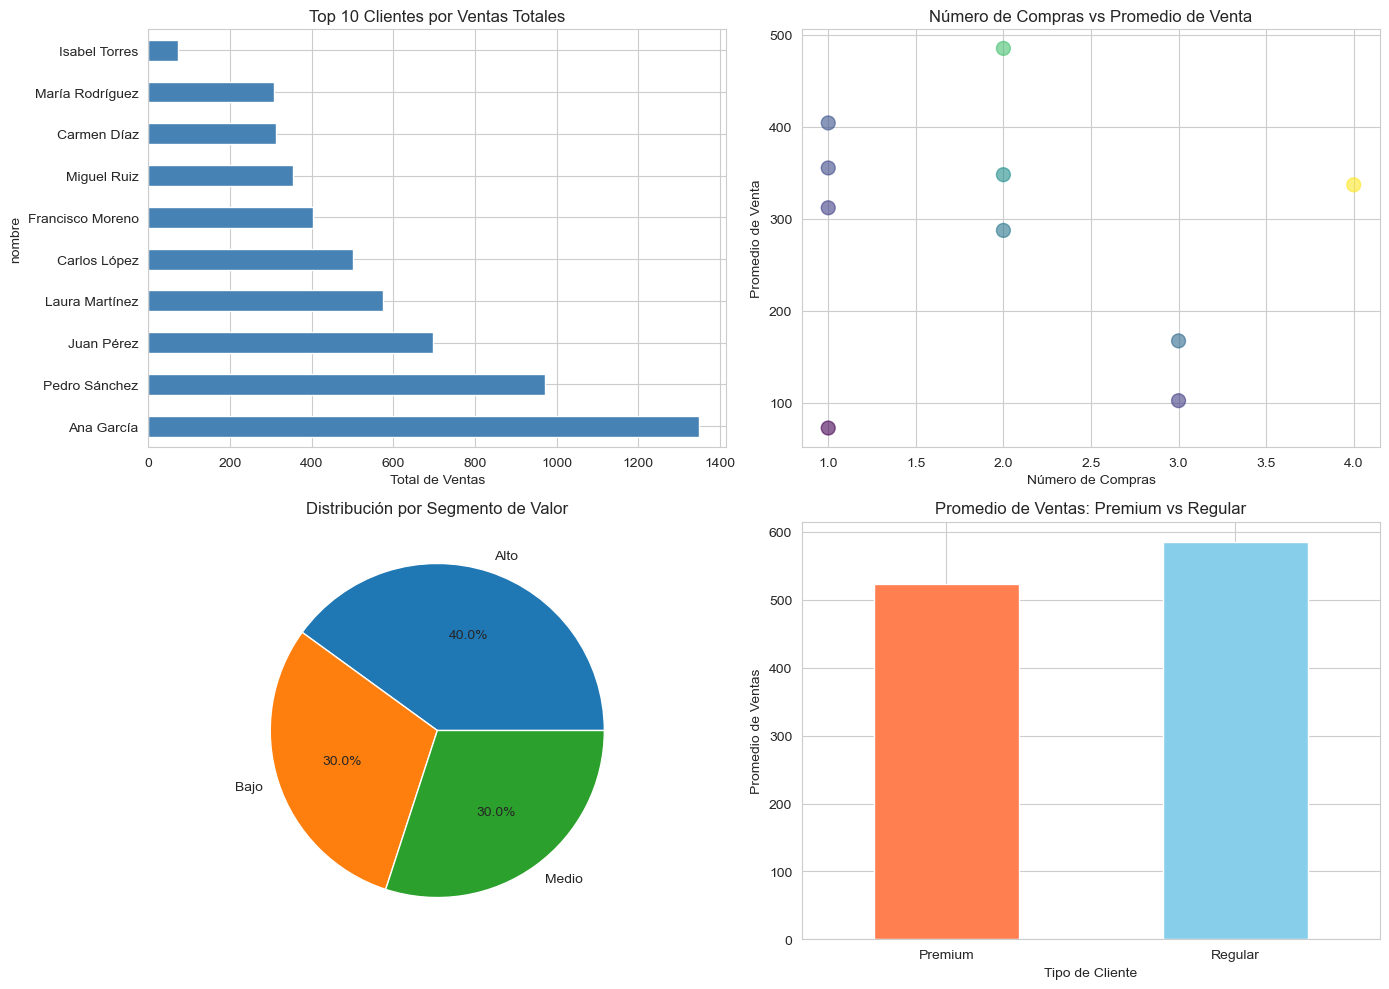

In [29]:
# Visualizar segmentos de clientes
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Total de ventas por cliente
metricas_cliente.sort_values('total_ventas', ascending=False).head(10).plot(
    x='nombre',
    y='total_ventas',
    kind='barh',
    ax=axes[0, 0],
    color='steelblue',
    legend=False
)
axes[0, 0].set_title('Top 10 Clientes por Ventas Totales')
axes[0, 0].set_xlabel('Total de Ventas')

# Número de compras vs promedio de venta
axes[0, 1].scatter(
    metricas_cliente['num_compras'],
    metricas_cliente['promedio_venta'],
    c=metricas_cliente['total_ventas'],
    cmap='viridis',
    s=100,
    alpha=0.6
)
axes[0, 1].set_title('Número de Compras vs Promedio de Venta')
axes[0, 1].set_xlabel('Número de Compras')
axes[0, 1].set_ylabel('Promedio de Venta')

# Distribución por segmento de valor
metricas_cliente['segmento_valor'].value_counts().plot(
    kind='pie',
    ax=axes[1, 0],
    autopct='%1.1f%%'
)
axes[1, 0].set_title('Distribución por Segmento de Valor')
axes[1, 0].set_ylabel('')

# Comparación Premium vs Regular
comparacion_tipo = metricas_cliente.groupby('tipo_cliente')['total_ventas'].mean()
comparacion_tipo.plot(kind='bar', ax=axes[1, 1], color=['coral', 'skyblue'])
axes[1, 1].set_title('Promedio de Ventas: Premium vs Regular')
axes[1, 1].set_ylabel('Promedio de Ventas')
axes[1, 1].set_xlabel('Tipo de Cliente')
axes[1, 1].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.show()

### 5.2 Análisis de Productos más Rentables por Región

In [30]:
# Análisis de rentabilidad por producto y región
rentabilidad = analisis_completo.groupby(['region', 'nombre_producto']).agg({
    'ganancia_total': 'sum',
    'total': 'sum',
    'cantidad': 'sum',
    'id_venta': 'count'
}).reset_index()

rentabilidad.columns = [
    'region', 'producto', 'ganancia', 'ventas', 'unidades', 'transacciones'
]

# ROI por producto y región
rentabilidad['roi_porcentaje'] = (rentabilidad['ganancia'] / rentabilidad['ventas'] * 100).round(2)

# Producto más vendido por región
idx_top = rentabilidad.groupby('region')['ganancia'].idxmax()
top_productos = rentabilidad.loc[idx_top]

print("Producto más rentable por región:")
print(top_productos.round(2))

# Crear pivot table
pivot_ganancia = rentabilidad.pivot_table(
    values='ganancia',
    index='region',
    columns='producto',
    aggfunc='sum',
    fill_value=0
)

print("\nGanancia por Región y Producto:")
print(pivot_ganancia.round(2))

Producto más rentable por región:
  region producto  ganancia   ventas  unidades  transacciones  roi_porcentaje
0   Este    Mouse   1023.18  1093.18        14              2           93.60
3  Norte    Mouse    604.52   664.52        12              2           90.97
6  Oeste    Mouse    763.70   828.70        13              2           92.16
9    Sur    Mouse    365.61   400.61         7              1           91.26

Ganancia por Región y Producto:
producto   Laptop    Mouse  Teclado
region                             
Este         0.00  1023.18   374.55
Norte    -2844.64   604.52   -14.60
Oeste    -2907.28   763.70   222.01
Sur      -6723.83   365.61     0.00


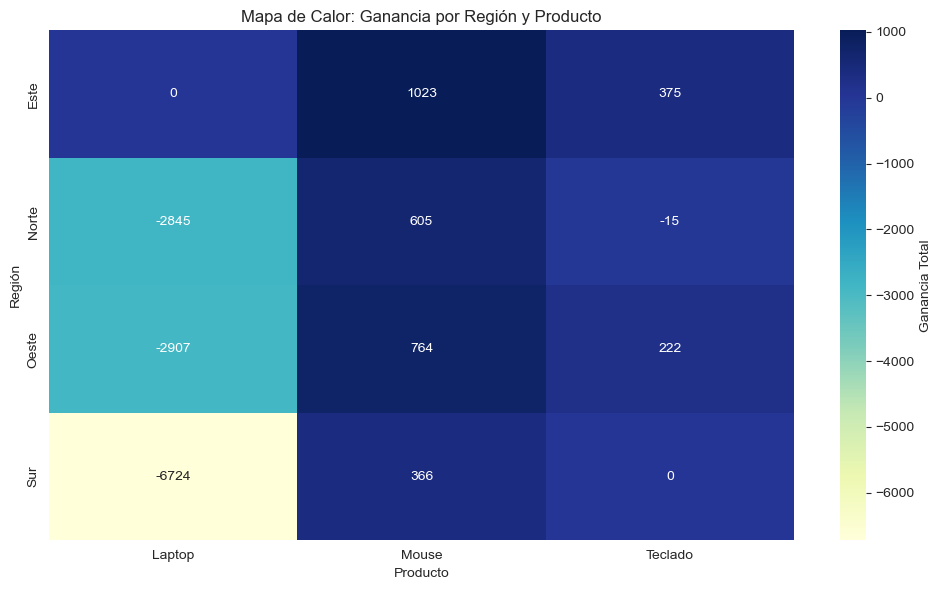

In [31]:
# Visualizar heatmap de rentabilidad
plt.figure(figsize=(10, 6))
sns.heatmap(
    pivot_ganancia,
    annot=True,
    fmt='.0f',
    cmap='YlGnBu',
    cbar_kws={'label': 'Ganancia Total'}
)
plt.title('Mapa de Calor: Ganancia por Región y Producto')
plt.xlabel('Producto')
plt.ylabel('Región')
plt.tight_layout()
plt.show()

## Resumen

En este notebook aprendimos:

### GroupBy y Agregaciones
- `groupby()` con una o múltiples columnas
- Funciones de agregación: `sum()`, `mean()`, `count()`, `min()`, `max()`, `std()`
- `agg()` para aplicar múltiples funciones
- `transform()` para mantener la forma original
- `apply()` para funciones personalizadas

### Joins
- **Inner Join**: Intersección de ambos DataFrames
- **Left Join**: Todas las filas del DataFrame izquierdo
- **Right Join**: Todas las filas del DataFrame derecho
- **Outer Join**: Unión de ambos DataFrames
- Uso de `left_on` y `right_on` para columnas con nombres diferentes
- Joins múltiples encadenados

### Creación de Variables
- Variables aritméticas simples
- Variables categóricas con `apply()`, `np.where()`, y `pd.cut()`
- Variables temporales con `.dt` accessor
- Variables de texto con `.str` accessor
- Variables agregadas: `cumsum()`, `cumcount()`, `rolling()`
- Variables de ranking con `rank()`
- One-hot encoding con `get_dummies()`

### Mejores Prácticas
- Siempre inspecciona tus datos antes y después de las operaciones
- Usa `reset_index()` cuando necesites convertir índices en columnas
- Maneja valores nulos apropiadamente con `fillna()`, `dropna()`
- Documenta tus transformaciones para reproducibilidad
- Visualiza tus resultados para validar las operaciones

Estas operaciones son fundamentales para el análisis exploratorio de datos y la ingeniería de features en machine learning.